# DVN AT3 EDA


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)
plt.style.use("seaborn-v0_8-whitegrid")


## Load Dataset


In [ ]:
# Load dataset

dataset_path = r"#dataset_path#"
master = pd.read_csv(dataset_path)
master["month_start"] = pd.to_datetime(master["month_start"])

print("Loaded datasets")
print("master detail:", master.shape)

print("MASTER DASHBOARD DATASET")
print("=" * 80)
print("Rows:", master.shape[0])
print("Columns:", master.shape[1])

print("\nColumn list:")
for i, col in enumerate(master.columns, start=1):
    print(f"{i:02d}. {col}")


Loaded datasets
master detail: (872, 23)
MASTER DASHBOARD DATASET
Rows: 872
Columns: 23

Column list:
01. month_start
02. year
03. quarter
04. month
05. month_name
06. year_month
07. state
08. state_name
09. city
10. fatalities
11. population
12. fatalities_per_100k_population
13. fatalities_per_million_population
14. avg_temp_mean
15. max_temp
16. min_temp
17. total_precipitation_mm
18. total_rain_mm
19. max_wind_speed_kmh
20. rainy_days
21. rain_context
22. heat_context
23. wind_context


## 1. Basic Master Data Validation


In [3]:
# ============================================================
# 1. BASIC MASTER DATA VALIDATION
# ============================================================

print("Year range:")
print(master["year"].min(), "to", master["year"].max())

print("\nStates:")
print(sorted(master["state"].dropna().unique()))

print("\nState names:")
print(sorted(master["state_name"].dropna().unique()))

print("\nCities used for weather context:")
print(sorted(master["city"].dropna().unique()))

print("\nMonth coverage by year:")
print(master.groupby("year")["month"].nunique())

print("\nPopulation availability:")
print("Rows with population:", master["population"].notna().sum())
print("Rows missing population:", master["population"].isna().sum())

print("\nWeather availability:")
weather_fields = [
    "avg_temp_mean",
    "max_temp",
    "min_temp",
    "total_precipitation_mm",
    "total_rain_mm",
    "max_wind_speed_kmh",
    "rainy_days",
    "rain_context",
    "heat_context",
    "wind_context",
]
print(master[weather_fields].notna().all(axis=1).value_counts())

print("\nFatalities field check:")
print(master["fatalities"].describe())

print("\nTotal fatalities:")
print(master["fatalities"].sum())

print("\nMissing values in key EDA fields:")
key_fields = [
    "month_start",
    "year",
    "quarter",
    "month",
    "month_name",
    "state",
    "state_name",
    "city",
    "fatalities",
    "population",
    "fatalities_per_100k_population",
    "avg_temp_mean",
    "max_temp",
    "total_rain_mm",
    "max_wind_speed_kmh",
    "rain_context",
    "heat_context",
    "wind_context",
]
print(master[key_fields].isna().sum())


Year range:
2017 to 2026

States:
['ACT', 'NSW', 'NT', 'QLD', 'SA', 'TAS', 'VIC', 'WA']

State names:
['Australian Capital Territory', 'New South Wales', 'Northern Territory', 'Queensland', 'South Australia', 'Tasmania', 'Victoria', 'Western Australia']

Cities used for weather context:
['Adelaide', 'Brisbane', 'Canberra', 'Darwin', 'Hobart', 'Melbourne', 'Perth', 'Sydney']

Month coverage by year:
year
2017    12
2018    12
2019    12
2020    12
2021    12
2022    12
2023    12
2024    12
2025    12
2026     1
Name: month, dtype: int64

Population availability:
Rows with population: 872
Rows missing population: 0

Weather availability:
True    872
Name: count, dtype: int64

Fatalities field check:
count    872.000000
mean      12.519495
std       10.490916
min        0.000000
25%        3.000000
50%       11.000000
75%       21.000000
max       42.000000
Name: fatalities, dtype: float64

Total fatalities:
10917

Missing values in key EDA fields:
month_start                       0
yea

## 2. Long-Term Annual Fatality Trend


Annual fatalities:
   year  fatalities  avg_population  months_covered  fatalities_per_100k     year_type
0  2017        1223     3073489.625              12            39.791903     Full year
1  2018        1135     3119816.625              12            36.380343     Full year
2  2019        1186     3166256.250              12            37.457486     Full year
3  2020        1097     3205555.625              12            34.221836     Full year
4  2021        1129     3210070.250              12            35.170570     Full year
5  2022        1182     3251725.000              12            36.349937     Full year
6  2023        1251     3331869.000              12            37.546494     Full year
7  2024        1292     3398661.375              12            38.014967     Full year
8  2025        1316     3451174.750              12            38.131943     Full year
9  2026         106     3451174.750               1             3.071418  Partial year

Highest fatality years:

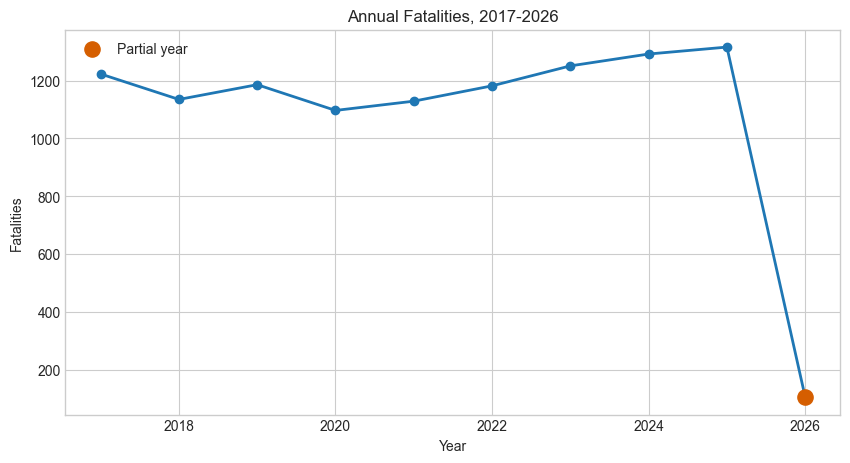

In [4]:
# ============================================================
# EDA 1: LONG-TERM ANNUAL FATALITY TREND
# ============================================================

annual_fatalities = (
    master
    .groupby("year", as_index=False)
    .agg(
        fatalities=("fatalities", "sum"),
        avg_population=("population", "mean"),
        months_covered=("month", "nunique")
    )
    .sort_values("year")
)

annual_fatalities["fatalities_per_100k"] = (
    annual_fatalities["fatalities"] /
    annual_fatalities["avg_population"] *
    100000
)

annual_fatalities["year_type"] = np.where(
    annual_fatalities["months_covered"] < 12,
    "Partial year",
    "Full year"
)

print("Annual fatalities:")
print(annual_fatalities)

print("\nHighest fatality years:")
print(annual_fatalities.sort_values("fatalities", ascending=False).head(10))

print("\nLowest full fatality years:")
print(
    annual_fatalities[annual_fatalities["year_type"] == "Full year"]
    .sort_values("fatalities", ascending=True)
    .head(10)
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(annual_fatalities["year"], annual_fatalities["fatalities"], marker="o", linewidth=2)
for _, row in annual_fatalities.iterrows():
    if row["year_type"] == "Partial year":
        ax.scatter(row["year"], row["fatalities"], s=120, color="#d55e00", zorder=3, label="Partial year")
ax.set_title("Annual Fatalities, 2017-2026")
ax.set_xlabel("Year")
ax.set_ylabel("Fatalities")
ax.legend(loc="best")
plt.show()


## 3. Recent Year Comparison


   year  fatalities  months_covered          note
0  2024        1292              12     Full year
1  2025        1316              12     Full year
2  2026         106               1  Partial year

Change from 2024 to 2025:
Absolute change: 24
Percent change: 1.86 %


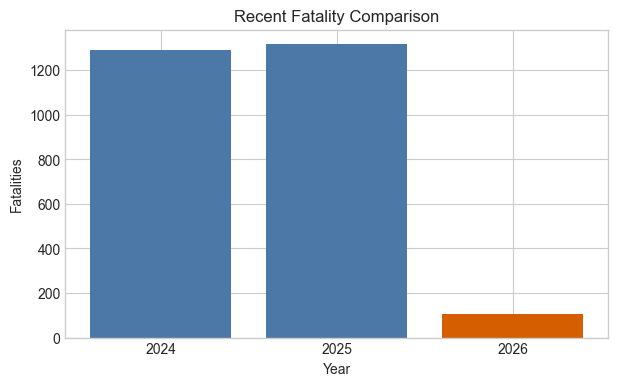

In [5]:
# ============================================================
# EDA 2: RECENT YEAR COMPARISON
# ============================================================

recent_year_comparison = (
    master[master["year"].isin([2024, 2025, 2026])]
    .groupby("year", as_index=False)
    .agg(
        fatalities=("fatalities", "sum"),
        months_covered=("month", "nunique")
    )
    .sort_values("year")
)

recent_year_comparison["note"] = np.where(
    recent_year_comparison["months_covered"] < 12,
    "Partial year",
    "Full year"
)

print(recent_year_comparison)

if {2024, 2025}.issubset(set(recent_year_comparison["year"])):
    fatalities_2024 = recent_year_comparison.loc[
        recent_year_comparison["year"] == 2024,
        "fatalities"
    ].iloc[0]

    fatalities_2025 = recent_year_comparison.loc[
        recent_year_comparison["year"] == 2025,
        "fatalities"
    ].iloc[0]

    change_2024_to_2025 = fatalities_2025 - fatalities_2024
    pct_change_2024_to_2025 = change_2024_to_2025 / fatalities_2024 * 100

    print("\nChange from 2024 to 2025:")
    print("Absolute change:", change_2024_to_2025)
    print("Percent change:", round(pct_change_2024_to_2025, 2), "%")

fig, ax = plt.subplots(figsize=(7, 4))
colors = ["#4c78a8" if note == "Full year" else "#d55e00" for note in recent_year_comparison["note"]]
ax.bar(recent_year_comparison["year"].astype(str), recent_year_comparison["fatalities"], color=colors)
ax.set_title("Recent Fatality Comparison")
ax.set_xlabel("Year")
ax.set_ylabel("Fatalities")
plt.show()


## 4. Analysis Windows and Working Subsets


In [6]:
# ============================================================
# WORKING SUBSETS
# ============================================================

historical = master[master["year"] <= 2023].copy()

latest = master[master["year"].isin([2024, 2025, 2026])].copy()

recent_full_years = master[master["year"].isin([2024, 2025])].copy()

rate_available = master[master["population"].notna()].copy()

weather_available = master[
    master[["rain_context", "heat_context", "wind_context"]].notna().all(axis=1)
].copy()

print("Historical rows:", historical.shape)
print("Latest rows:", latest.shape)
print("Recent full years rows:", recent_full_years.shape)
print("Population-rate available rows:", rate_available.shape)
print("Weather available rows:", weather_available.shape)


Historical rows: (672, 23)
Latest rows: (200, 23)
Recent full years rows: (192, 23)
Population-rate available rows: (872, 23)
Weather available rows: (872, 23)


## 5. State Risk, Raw vs Population-Adjusted


State risk, 2024-2025:
  state                    state_name       city  fatalities  avg_population  avg_monthly_rate_per_100k  fatalities_per_100k_two_year_total  \
2    NT            Northern Territory     Darwin          98        262647.5                   1.557096                           37.312367   
5   TAS                      Tasmania     Hobart          75        575362.5                   0.543039                           13.035260   
7    WA             Western Australia      Perth         371       3010939.0                   0.513542                           12.321738   
3   QLD                    Queensland   Brisbane         609       5620862.0                   0.451445                           10.834637   
4    SA               South Australia   Adelaide         176       1892247.5                   0.387581                            9.301109   
6   VIC                      Victoria  Melbourne         574       7012714.5                   0.341042                

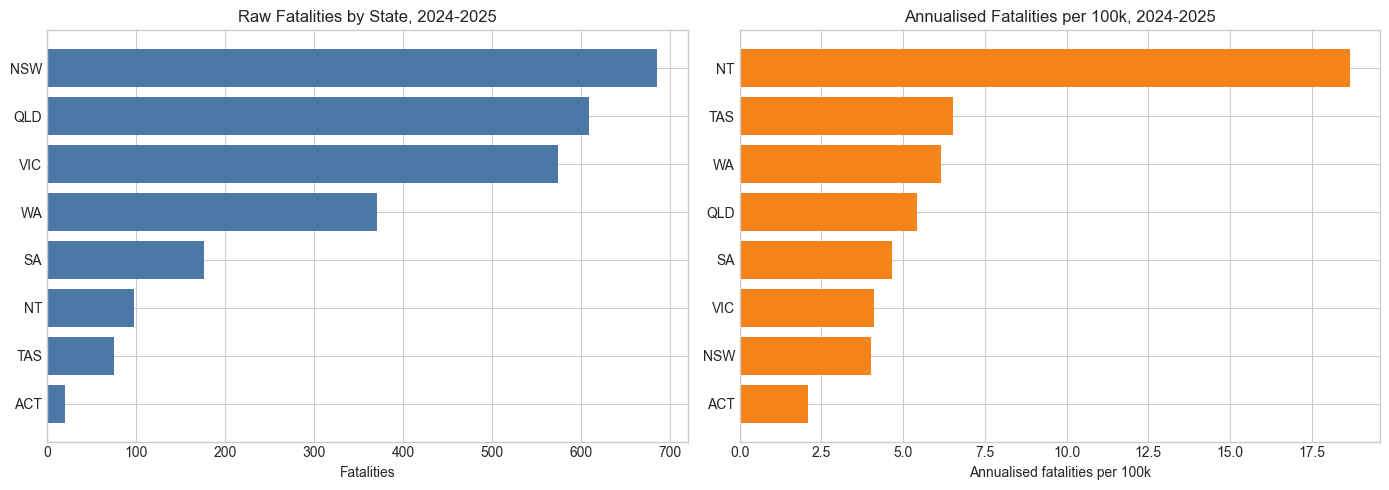

In [7]:
# ============================================================
# EDA 3: STATE RISK, RAW VS POPULATION-ADJUSTED
# Uses 2024-2025 only for fair full-year comparison
# ============================================================

state_risk_recent = (
    recent_full_years
    .groupby(["state", "state_name", "city"], as_index=False)
    .agg(
        fatalities=("fatalities", "sum"),
        avg_population=("population", "mean"),
        avg_monthly_rate_per_100k=("fatalities_per_100k_population", "mean")
    )
)

state_risk_recent["fatalities_per_100k_two_year_total"] = (
    state_risk_recent["fatalities"] /
    state_risk_recent["avg_population"] *
    100000
)

state_risk_recent["annualised_fatalities_per_100k"] = (
    state_risk_recent["fatalities_per_100k_two_year_total"] / 2
)

state_risk_recent = state_risk_recent.sort_values(
    "annualised_fatalities_per_100k",
    ascending=False
)

print("State risk, 2024-2025:")
print(state_risk_recent)

print("\nRaw fatalities ranking:")
print(
    state_risk_recent
    .sort_values("fatalities", ascending=False)
    [["state", "state_name", "fatalities"]]
)

print("\nPopulation-adjusted ranking:")
print(
    state_risk_recent
    .sort_values("annualised_fatalities_per_100k", ascending=False)
    [["state", "state_name", "annualised_fatalities_per_100k"]]
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
raw = state_risk_recent.sort_values("fatalities", ascending=True)
axes[0].barh(raw["state"], raw["fatalities"], color="#4c78a8")
axes[0].set_title("Raw Fatalities by State, 2024-2025")
axes[0].set_xlabel("Fatalities")

rate = state_risk_recent.sort_values("annualised_fatalities_per_100k", ascending=True)
axes[1].barh(rate["state"], rate["annualised_fatalities_per_100k"], color="#f58518")
axes[1].set_title("Annualised Fatalities per 100k, 2024-2025")
axes[1].set_xlabel("Annualised fatalities per 100k")
plt.tight_layout()
plt.show()


## 6. Monthly and Seasonal Fatality Patterns


Monthly pattern, full years only:


    month month_name  fatalities  avg_fatalities_per_state_month
0       1    January         895                       12.430556
1       2   February         822                       11.416667
2       3      March         957                       13.291667
3       4      April         872                       12.111111
4       5        May         890                       12.361111
5       6       June         832                       11.555556
6       7       July         913                       12.680556
7       8     August         902                       12.527778
8       9  September         899                       12.486111
9      10    October         903                       12.541667
10     11   November         939                       13.041667
11     12   December         987                       13.708333

Quarter pattern, full years only:
   quarter  fatalities  avg_fatalities_per_state_month
0        1        2674                       12.379630
1        

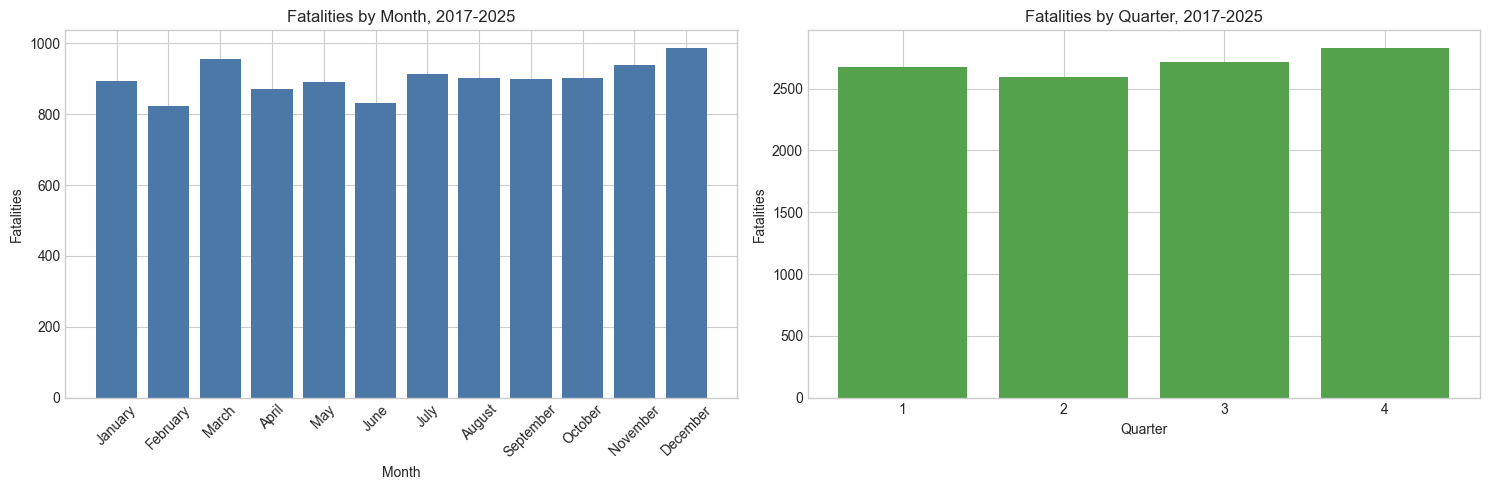

In [8]:
# ============================================================
# EDA 4: MONTHLY AND SEASONAL PATTERN
# Adapted replacement for original day x time pattern
# ============================================================

month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]

monthly_pattern = (
    master[master["year"] <= 2025]
    .groupby(["month", "month_name"], as_index=False)
    .agg(
        fatalities=("fatalities", "sum"),
        avg_fatalities_per_state_month=("fatalities", "mean")
    )
)

monthly_pattern["month_name"] = pd.Categorical(
    monthly_pattern["month_name"],
    categories=month_order,
    ordered=True
)
monthly_pattern = monthly_pattern.sort_values("month")

quarter_pattern = (
    master[master["year"] <= 2025]
    .groupby("quarter", as_index=False)
    .agg(
        fatalities=("fatalities", "sum"),
        avg_fatalities_per_state_month=("fatalities", "mean")
    )
    .sort_values("quarter")
)

print("Monthly pattern, full years only:")
print(monthly_pattern)

print("\nQuarter pattern, full years only:")
print(quarter_pattern)

print("\nHighest fatality months:")
print(monthly_pattern.sort_values("fatalities", ascending=False).head(5))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].bar(monthly_pattern["month_name"].astype(str), monthly_pattern["fatalities"], color="#4c78a8")
axes[0].set_title("Fatalities by Month, 2017-2025")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Fatalities")
axes[0].tick_params(axis="x", rotation=45)

axes[1].bar(quarter_pattern["quarter"].astype(str), quarter_pattern["fatalities"], color="#54a24b")
axes[1].set_title("Fatalities by Quarter, 2017-2025")
axes[1].set_xlabel("Quarter")
axes[1].set_ylabel("Fatalities")
plt.tight_layout()
plt.show()


## 7. State-City Risk Segments


In [9]:
# ============================================================
# EDA 5: STATE-CITY RISK SEGMENTS
# Adapted replacement for road environment and risk segments
# ============================================================

state_city_latest = (
    latest
    .groupby(["state", "state_name", "city"], as_index=False)
    .agg(
        fatalities=("fatalities", "sum"),
        avg_population=("population", "mean"),
        avg_rate_per_100k=("fatalities_per_100k_population", "mean"),
        max_monthly_fatalities=("fatalities", "max")
    )
    .sort_values("fatalities", ascending=False)
)

state_city_latest["share_of_latest"] = (
    state_city_latest["fatalities"] / latest["fatalities"].sum()
)

print("State-city risk segments, latest window:")
print(state_city_latest)

print("\nTop state-city segments by raw fatalities:")
print(state_city_latest.head(10))

print("\nTop state-city segments by population-adjusted monthly risk:")
print(state_city_latest.sort_values("avg_rate_per_100k", ascending=False).head(10))


State-city risk segments, latest window:
  state                    state_name       city  fatalities  avg_population  avg_rate_per_100k  max_monthly_fatalities  share_of_latest
1   NSW               New South Wales     Sydney         711      8544996.92           0.332758                      41         0.261975
3   QLD                    Queensland   Brisbane         631      5622820.88           0.448908                      42         0.232498
6   VIC                      Victoria  Melbourne         596      7015184.64           0.339840                      38         0.219602
7    WA             Western Australia      Perth         387      3012250.68           0.514027                      25         0.142594
4    SA               South Australia   Adelaide         187      1892650.84           0.395207                      12         0.068902
2    NT            Northern Territory     Darwin          99       262718.04           1.509940                       9         0.036478


## 8. State x Season Matrix


State x quarter fatality matrix, latest window:
quarter    1    2    3    4
state                      
ACT        8    4    1   10
NSW      181  182  153  195
NT        25   28   28   18
QLD      152  151  159  169
SA        55   37   44   51
TAS       18   21   25   16
VIC      174  131  150  141
WA       116   93   83   95

Top state-quarter cells:
   state  quarter  fatalities
7    NSW        4         195
5    NSW        2         182
4    NSW        1         181
24   VIC        1         174
15   QLD        4         169
14   QLD        3         159
6    NSW        3         153
12   QLD        1         152
13   QLD        2         151
26   VIC        3         150


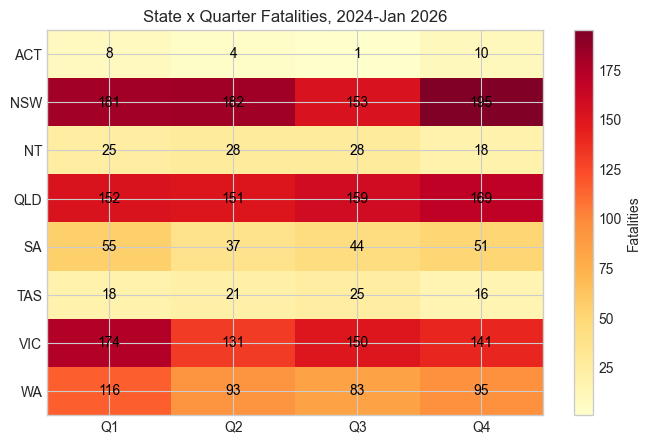

In [10]:
# ============================================================
# EDA 6: STATE x QUARTER MATRIX
# Adapted replacement for remoteness x speed matrix
# ============================================================

state_quarter_latest = (
    latest
    .groupby(["state", "quarter"], as_index=False)
    .agg(fatalities=("fatalities", "sum"))
    .sort_values(["state", "quarter"])
)

state_quarter_matrix = state_quarter_latest.pivot(
    index="state",
    columns="quarter",
    values="fatalities"
).fillna(0).astype(int)

print("State x quarter fatality matrix, latest window:")
print(state_quarter_matrix)

print("\nTop state-quarter cells:")
print(state_quarter_latest.sort_values("fatalities", ascending=False).head(10))

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(state_quarter_matrix.values, aspect="auto", cmap="YlOrRd")
ax.set_xticks(range(len(state_quarter_matrix.columns)))
ax.set_xticklabels([f"Q{q}" for q in state_quarter_matrix.columns])
ax.set_yticks(range(len(state_quarter_matrix.index)))
ax.set_yticklabels(state_quarter_matrix.index)
ax.set_title("State x Quarter Fatalities, 2024-Jan 2026")
for i in range(state_quarter_matrix.shape[0]):
    for j in range(state_quarter_matrix.shape[1]):
        ax.text(j, i, state_quarter_matrix.values[i, j], ha="center", va="center", color="black")
fig.colorbar(im, ax=ax, label="Fatalities")
plt.show()


## 9. Weather Context


Fatalities by rain context:
    rain_context  fatalities  avg_monthly_fatalities  rows
0      High rain        4797               15.884106   302
2  Moderate rain        4633               11.163855   415
1       Low rain        1487                9.593548   155

Fatalities by heat context:
  heat_context  fatalities  avg_monthly_fatalities  rows
2    Below 30C        4656               11.787342   395
0       30-35C        3213               10.534426   305
1    Above 35C        3048               17.720930   172

Fatalities by wind context:
    wind_context  fatalities  avg_monthly_fatalities  rows
1       Low wind       10063               12.438813   809
2  Moderate wind         854               13.774194    62
0      High wind           0                0.000000     1


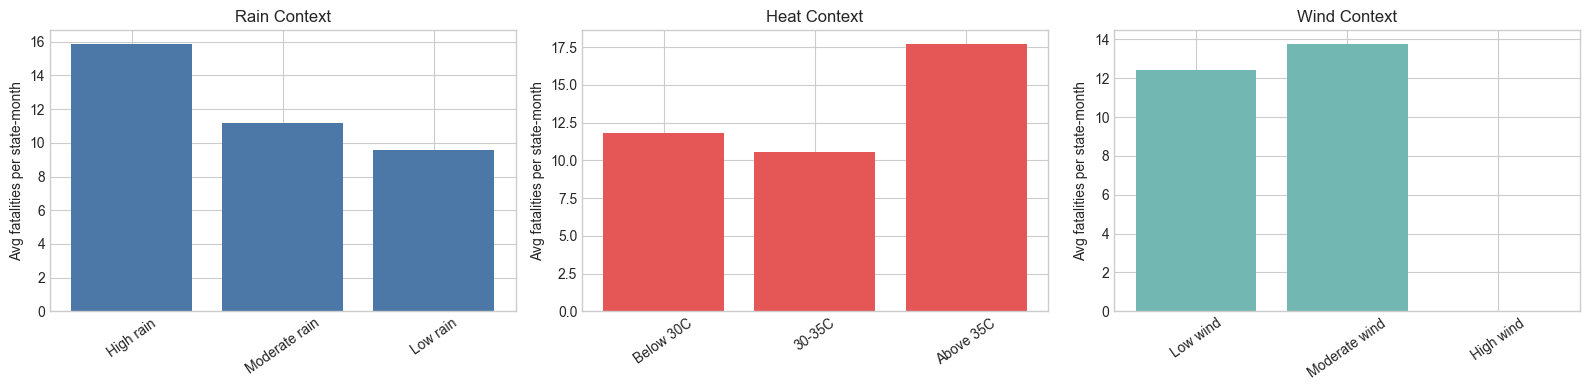

In [11]:
# ============================================================
# EDA 7: WEATHER CONTEXT
# Weather is state-month context, not exact crash-site causation
# ============================================================

weather_latest = weather_available.copy()

weather_rain_context = (
    weather_latest
    .groupby("rain_context", as_index=False)
    .agg(
        fatalities=("fatalities", "sum"),
        avg_monthly_fatalities=("fatalities", "mean"),
        rows=("fatalities", "size")
    )
    .sort_values("fatalities", ascending=False)
)

weather_heat_context = (
    weather_latest
    .groupby("heat_context", as_index=False)
    .agg(
        fatalities=("fatalities", "sum"),
        avg_monthly_fatalities=("fatalities", "mean"),
        rows=("fatalities", "size")
    )
    .sort_values("fatalities", ascending=False)
)

weather_wind_context = (
    weather_latest
    .groupby("wind_context", as_index=False)
    .agg(
        fatalities=("fatalities", "sum"),
        avg_monthly_fatalities=("fatalities", "mean"),
        rows=("fatalities", "size")
    )
    .sort_values("fatalities", ascending=False)
)

print("Fatalities by rain context:")
print(weather_rain_context)

print("\nFatalities by heat context:")
print(weather_heat_context)

print("\nFatalities by wind context:")
print(weather_wind_context)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, data, col, title, color in [
    (axes[0], weather_rain_context, "rain_context", "Rain Context", "#4c78a8"),
    (axes[1], weather_heat_context, "heat_context", "Heat Context", "#e45756"),
    (axes[2], weather_wind_context, "wind_context", "Wind Context", "#72b7b2"),
]:
    ax.bar(data[col], data["avg_monthly_fatalities"], color=color)
    ax.set_title(title)
    ax.set_ylabel("Avg fatalities per state-month")
    ax.tick_params(axis="x", rotation=35)
plt.tight_layout()
plt.show()


## 10. Continuous Weather Relationships


Correlation with raw fatalities and population-adjusted fatalities:
                                fatalities  fatalities_per_100k_population
fatalities                        1.000000                       -0.069816
max_temp                          0.179606                        0.182823
rainy_days                        0.110636                        0.048829
total_rain_mm                     0.066345                        0.135328
total_precipitation_mm            0.065706                        0.134965
avg_temp_mean                     0.063093                        0.424227
max_wind_speed_kmh                0.056879                       -0.153872
min_temp                          0.056700                        0.496072
fatalities_per_100k_population   -0.069816                        1.000000


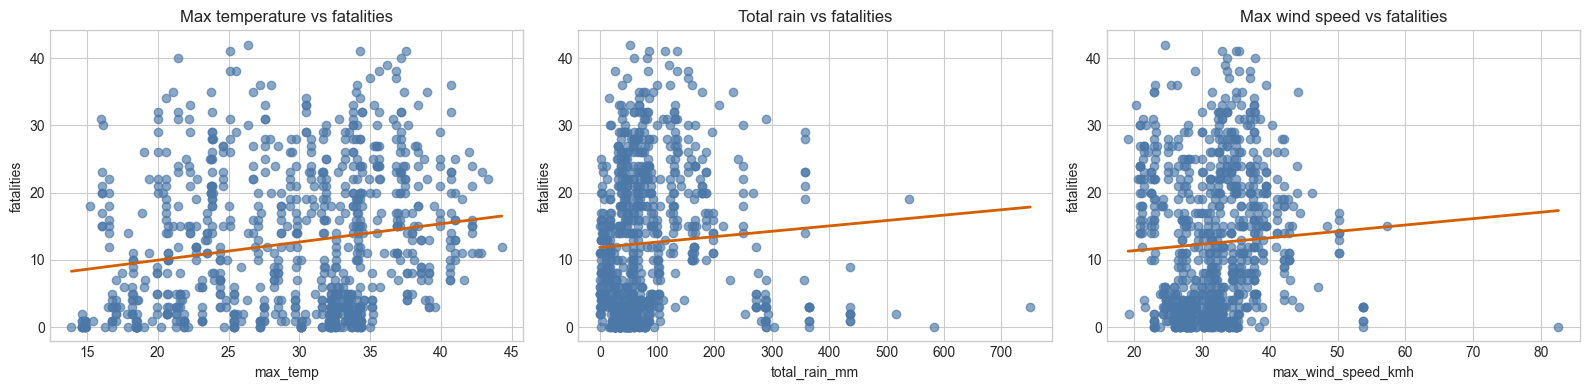

In [12]:
# ============================================================
# EDA 8: CONTINUOUS WEATHER RELATIONSHIPS
# Best-fit EDA added for final integrated weather dataset
# ============================================================

weather_numeric = [
    "avg_temp_mean",
    "max_temp",
    "min_temp",
    "total_rain_mm",
    "total_precipitation_mm",
    "max_wind_speed_kmh",
    "rainy_days",
    "fatalities",
    "fatalities_per_100k_population",
]

weather_correlations = (
    master[weather_numeric]
    .corr(numeric_only=True)[["fatalities", "fatalities_per_100k_population"]]
    .sort_values("fatalities", ascending=False)
)

print("Correlation with raw fatalities and population-adjusted fatalities:")
print(weather_correlations)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
scatter_specs = [
    ("max_temp", "fatalities", "Max temperature vs fatalities"),
    ("total_rain_mm", "fatalities", "Total rain vs fatalities"),
    ("max_wind_speed_kmh", "fatalities", "Max wind speed vs fatalities"),
]
for ax, (x, y, title) in zip(axes, scatter_specs):
    ax.scatter(master[x], master[y], alpha=0.65, color="#4c78a8")
    z = np.polyfit(master[x], master[y], 1)
    p = np.poly1d(z)
    xs = np.linspace(master[x].min(), master[x].max(), 100)
    ax.plot(xs, p(xs), color="#d55e00", linewidth=2)
    ax.set_title(title)
    ax.set_xlabel(x)
    ax.set_ylabel(y)
plt.tight_layout()
plt.show()


## 11. Policy Priority State-Month Segments


Top 20 policy priority state-month segments:
    year_month state          state_name       city  fatalities  population  fatalities_per_100k_population   rain_context heat_context   wind_context  \
785    2025-03   NSW     New South Wales     Sydney          41     8593871                        0.477084      High rain    Above 35C       Low wind   
827    2025-08   QLD          Queensland   Brisbane          42     5669834                        0.740762  Moderate rain    Below 30C       Low wind   
753    2024-11   NSW     New South Wales     Sydney          39     8492050                        0.459253      High rain    Above 35C       Low wind   
774    2025-01   VIC            Victoria  Melbourne          36     7074468                        0.508872  Moderate rain    Above 35C       Low wind   
758    2024-11   VIC            Victoria  Melbourne          35     6950961                        0.503527      High rain    Above 35C  Moderate wind   
849    2025-11   NSW     New So

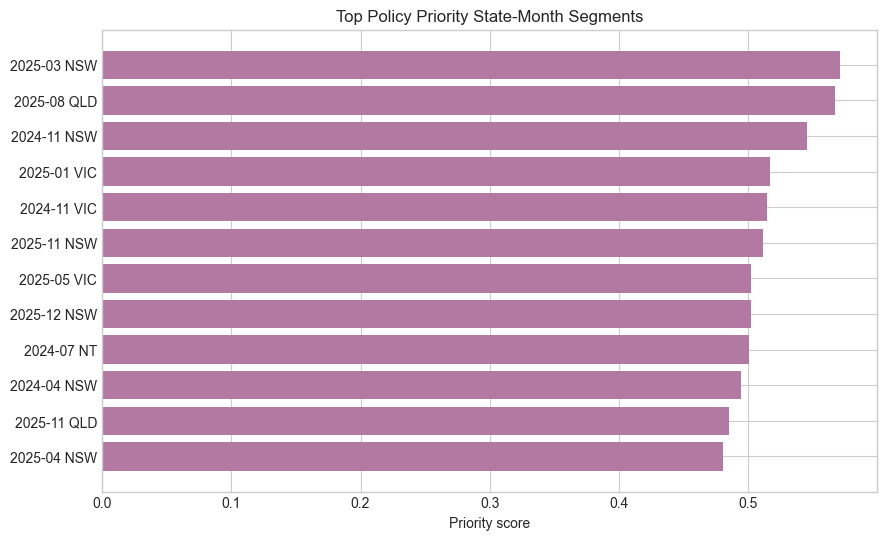

In [13]:
# ============================================================
# EDA 9: POLICY PRIORITY STATE-MONTH SEGMENTS
# Best-fit EDA added for funding-priority narrative
# ============================================================

priority = latest.copy()

for col in ["fatalities", "fatalities_per_100k_population", "max_temp", "total_rain_mm", "max_wind_speed_kmh"]:
    span = priority[col].max() - priority[col].min()
    if span == 0:
        priority[f"{col}_score"] = 0
    else:
        priority[f"{col}_score"] = (priority[col] - priority[col].min()) / span

priority["policy_priority_score"] = (
    priority["fatalities_score"] * 0.45 +
    priority["fatalities_per_100k_population_score"] * 0.35 +
    priority["max_temp_score"] * 0.08 +
    priority["total_rain_mm_score"] * 0.07 +
    priority["max_wind_speed_kmh_score"] * 0.05
)

priority_cols = [
    "year_month",
    "state",
    "state_name",
    "city",
    "fatalities",
    "population",
    "fatalities_per_100k_population",
    "rain_context",
    "heat_context",
    "wind_context",
    "policy_priority_score",
]

top_priority_segments = (
    priority[priority_cols]
    .sort_values("policy_priority_score", ascending=False)
    .head(20)
)

print("Top 20 policy priority state-month segments:")
print(top_priority_segments)

print("\nHighest fatality state-months:")
print(
    latest
    .sort_values(["fatalities", "fatalities_per_100k_population"], ascending=False)
    [["year_month", "state", "state_name", "city", "fatalities", "fatalities_per_100k_population"]]
    .head(20)
)

print("\nHighest population-adjusted risk state-months:")
print(
    latest
    .sort_values(["fatalities_per_100k_population", "fatalities"], ascending=False)
    [["year_month", "state", "state_name", "city", "fatalities", "fatalities_per_100k_population"]]
    .head(20)
)

plot_priority = top_priority_segments.sort_values("policy_priority_score", ascending=True).tail(12)
labels = plot_priority["year_month"] + " " + plot_priority["state"]
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(labels, plot_priority["policy_priority_score"], color="#b279a2")
ax.set_title("Top Policy Priority State-Month Segments")
ax.set_xlabel("Priority score")
plt.show()


## 12. Narrative Findings for Dashboard Story


In [14]:
# ============================================================
# NARRATIVE FINDINGS
# ============================================================

latest_total = latest["fatalities"].sum()
full_recent_total = recent_full_years["fatalities"].sum()
top_raw_state = state_risk_recent.sort_values("fatalities", ascending=False).iloc[0]
top_rate_state = state_risk_recent.sort_values("annualised_fatalities_per_100k", ascending=False).iloc[0]
top_month = monthly_pattern.sort_values("fatalities", ascending=False).iloc[0]
top_priority = top_priority_segments.iloc[0]

print("Key EDA findings for the data narrative:")
print("=" * 80)
print(f"1. The integrated dataset contains {master.shape[0]} state-month rows and {master.shape[1]} columns.")
print(f"2. The dataset covers {master['year'].min()} to {master['year'].max()}, with 2026 treated as a partial year.")
print(f"3. Total fatalities represented in this integrated file: {master['fatalities'].sum():,.0f}.")
print(f"4. Latest-window fatalities across 2024-Jan 2026: {latest_total:,.0f}.")
print(f"5. Highest raw recent burden: {top_raw_state['state']} ({top_raw_state['state_name']}) with {top_raw_state['fatalities']:,.0f} fatalities in 2024-2025.")
print(f"6. Highest annualised population-adjusted recent risk: {top_rate_state['state']} ({top_rate_state['state_name']}) at {top_rate_state['annualised_fatalities_per_100k']:.2f} fatalities per 100k.")
print(f"7. Highest full-year seasonal month by total fatalities: {top_month['month_name']} with {top_month['fatalities']:,.0f} fatalities across 2017-2025.")
print(f"8. Highest priority state-month segment in this scoring model: {top_priority['year_month']} {top_priority['state']} with score {top_priority['policy_priority_score']:.3f}.")

print("\nInterpretation caution:")
print("Weather fields are state-month representative context. They help describe conditions around fatality clusters, but they do not prove crash-level weather causation.")


Key EDA findings for the data narrative:
1. The integrated dataset contains 872 state-month rows and 23 columns.
2. The dataset covers 2017 to 2026, with 2026 treated as a partial year.
3. Total fatalities represented in this integrated file: 10,917.
4. Latest-window fatalities across 2024-Jan 2026: 2,714.
5. Highest raw recent burden: NSW (New South Wales) with 685 fatalities in 2024-2025.
6. Highest annualised population-adjusted recent risk: NT (Northern Territory) at 18.66 fatalities per 100k.
7. Highest full-year seasonal month by total fatalities: December with 987 fatalities across 2017-2025.
8. Highest priority state-month segment in this scoring model: 2025-03 NSW with score 0.571.

Interpretation caution:
Weather fields are state-month representative context. They help describe conditions around fatality clusters, but they do not prove crash-level weather causation.
